# Python中的第三方函数库

Pyrthon中最重要的三个函数库是NumpPy、SciPy和pandas。numpy是Python的数值计算扩展，专门用来处理矩阵，它的运算效率比列表更高效。scipy是基于numpy的科学计算包，包括统计、线性代数等工具。pandas是基于numpy的数据分析工具，能更方便的操作大型数据集。后续的章节主要围绕pandas讲解。

# Numpy库

在Python内置环境中，直接存储数值的数组对象只存在一维结构，无法支持多维结构，也没有相关数组运算函数，这使得Python在数值运算上有诸多不便之处。Numpy的核心功能是高维数组，Numpy库中的ndarray（N-dimensional array object）对象支持多维数组，ndarray中的元素数据类型相同。

In [2]:
import numpy as np

复习：面向对象中的几点概念

- 类：用户定义的对象原型（prototype），该原型定义了一组可描述该类任何对象的属性，属性是数据成员（类变量 和 实例变量）和方法，可以通过 ‘.’ 来访问。说简单一点，类是一个模板，我们可以使用该模板生成不同的具体的对象，来完成我们想要的操作

- 实例化对象：某一个类的单个对象，例如我们定义了一个 Person 类，而具体的人，比如小明，小黄就是 Person 类的实例

- 属性：描述该类具有的特征，比如人类具备的属性，身份证，姓名，性别，身高，体重等等都是属性

- 方法：是该类对象的行为，例如这个男孩会打篮球，那个女孩会唱歌等等都是属于方法，常常通过方法改变一些类中的属性值

在 python 面向对象中，总共包括五类（属性 + 方法）

- 类属性
- 实例属性
- 类方法
- 实例方法
- 静态方法

类体中的属性，指的就是类中的变量。

在类体中，根据变量定义的位置不同，以及定义的方式不同，类中的属性可细分为以下三种类型，如下所示：

- 类体中，所有方法之外：此范围定义的变量，称为类属性或类变量；
- 类体中，所有方法内部：以“self.变量名”的方式定义的变量，称为实例属性或实例变量；
- 类体中，所有方法内部：以“变量名 = 变量值”的方式定义的变量，称为局部变量。

In [1]:
class A(object):

    # 类属性: 直接在类中定义的属性
    count = 0

    def __init__(self):
        self.name = 'swk' # 实例属性

In [3]:
a = A() # a就是类A实例化的对象（也可以叫实例对象）

In [5]:
# 实例属性可以通过实例对象直接访问到
print(a.name)

swk


In [6]:
# 实例属性不可以通过类调用
print(A.name)

AttributeError: type object 'A' has no attribute 'name'

In [7]:
# 实例属性可以通过实例对象修改
a.name = 'zju'
print(a.name)

zju


In [8]:
# 类属性可以通过类对象直接访问到
print(A.count)

0


Python中实例的属性不一定需要放在类中方法外来定义，我们可以在类体之外为实例新增属性，或在类体之外删除某个属性。当我们使用实例对象引用类属性时，会产生一个同名的实例属性。此方式不建议使用，因为如果实例属性和类属性同名时，使用实例属性将无法调用类属性，它会首选实例属性。

In [9]:
# 实例对象引用类属性时，会产生一个同名的实例属性
print(a.count)

0


In [10]:
a.count=100 # 修改的只是实例属性，不会影响到类属性
print(a.count)
print(A.count)

100
0


In [11]:
del a.count # 删除实例属性
#print(a.count)

In [14]:
# shape属性
# 类实例化为对象
array1 = np.array([1,2,3,4,5,6])

print(array1)

[1 2 3 4 5 6]


In [15]:
# 通过对象调用属性
array1.shape

(6,)

In [16]:
# 通过对象调用方法改变属性
array11 = array1.reshape(6,-1)
array11.shape

(6, 1)

In [17]:
array1.shape

(6,)

从shape属性可以看出array1是一维数组，我们可以通过改变属性将其变成多维数组

In [18]:
# 直接改变属性
array1.shape = 2,3
array1.shape
print(array1.shape)

(2, 3)


In [19]:
print(array1)

[[1 2 3]
 [4 5 6]]


多维数组也可以通过`array()`直接创建

In [20]:
array3 = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(array3)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [21]:
array3.shape

(3, 3)

In [22]:
array4 = np.array([[1],[2],[3],[4],[5],[6]])
array4.shape

(6, 1)

In [23]:
print(array4)

[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]


In [24]:
a = np.zeros((4,5))
print(a)
a.dtype

np.ones((2,5,4))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

## 数组元素的索引和切片

我们可以通过数组中元素所在的索引值来提取单个元素或多个元素，方法为`array[start:end:step,start:end:step,...,start:end:step]`, 其中每一组`start:end:step`代表了在一个维度上的取值，其中start是起始索引值，end是结束索引值，step是步长值，返回的结果是索引值为start到end-1之间，并且是索引值与start之间可以被step整除的连续对象。

与list结构中取数据方式一样，数组的索引和步长都有两种取值方式，分别表示左右两个方向取值。索引的正方向取值从左向右，起始位置为0，结束位置为`len(array)-1`,负方向从右向左取值，起始位置为-1，结束位置为`-len(array)`.也就是说每个元素其实存在两个位置索引，一个是正的，一个是负的，比如最左边的元素的位置索引是0或者`-len(array)`,而最右边的元素的位置索引是`len(array)-1`或者是-1.

### 一维数组

具体来说一维数组的切片（slice）方式有两种：

- 位置切片:直接输入所要切片的元素的位置
- 列表（list）切片：将所要切片的元素的位置放入一个list，再进行切片

#### 位置切片

以下代码是位置切片的例子

In [25]:
a1 = np.linspace(1,26,6, dtype = int)

print(a1)

print(a1[1:3])

print(a1[:5])

print(a1[2:])

[ 1  6 11 16 21 26]
[ 6 11]
[ 1  6 11 16 21]
[11 16 21 26]


In [26]:
# 数组中的索引为负数时，表示从右向左方向上的位置
print(a1[-1])

print(a1[:-1])

# 起始值是索引值为2的元素，结束值是索引值为-1的前一个值（-2）,负的index -2 也就是正的index 5
a1[2:-1]

26
[ 1  6 11 16 21]


array([11, 16, 21])

关于位置切片的注意事项：
- 如果step的符号是正的，那么start的位置必须在stop的位置左边；
- 如果step的符号是负的，那么start的位置必须在stop的位置右边；
- 表示start和stop的取值可以是正的index，也可以是负的index

In [54]:
# 起始值是索引值为2的元素，结束值是索引值为-1的前一个值（-2）
print(a1[2:-1:1])
# 等价的表示方法, 注意len(a1) = 6
print(a1[2:5:1])

[11 16 21]
[11 16 21]


In [55]:
print(a1[5:2:-1])

#注意对比
print(a1[2:5:-1])

[26 21 16]
[]


#### 列表切片

使用list提取数组中的元素

In [22]:
a1[[0,1,4]]

array([ 1,  6, 21])

### 多维数组

与一维数组类似，但是需要分别考虑各个维度上的索引值

In [67]:
# 创建一个二维结构数组，第0轴长度为4，第1轴长度为6
na1 = np.array(np.arange(24),dtype=int).reshape(4,6)
print(na1)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]


In [27]:
# 创建一个二维结构数组，第0轴长度为6，第1轴长度为4
# 排序时默认先按行放置元素
na1 = np.array(np.arange(24),dtype=int).reshape(6,4)
print(na1)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [28]:
# 设置order = 'F'改为先按列排
na2 = np.array(np.arange(24),dtype=int).reshape((4,6), order = 'F')
print(na2)

[[ 0  4  8 12 16 20]
 [ 1  5  9 13 17 21]
 [ 2  6 10 14 18 22]
 [ 3  7 11 15 19 23]]


In [29]:
# 使用参数-1，.reshape（）方法会自动根据原有数组的元素数量设置适当的行数或者列数
na1 = np.array(np.arange(24),dtype=int).reshape(-1,6)
print(na1)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]


In [30]:
# 在第0轴上，取索引值为0，1的元素，共两行；在第1轴上，取索引值为1，2，3，4，5的元素，共5列
na1[:2,1:]

array([[ 1,  2,  3,  4,  5],
       [ 7,  8,  9, 10, 11]])

在多维数组中，采用list索引和直接索引的含义是不同的，可以从以下例子中看出来：

In [31]:
print(na1)

# 采用list来索引，在第0轴上取索引值[2,3], 在第1轴上取索引值[2,3], 这样取到的是na1[2,2]和na1[3,3]
print(na1[[2,3],[2,3]])

# 比较直接索引和list索引,注意这里2:4的结果是[2,3]
print(na1[2:4,2:4])

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]
[14 21]
[[14 15]
 [20 21]]


可以看出，采用list索引方式取得的元素是把不同维度上的list取值一一对应，所以如果所有维度都是是用list来索引，那么不同维度上使用的list的长度必须是一样的，这时取得的元素个数就是list的长度。NumPy允许在不同的维度采用不同的索引方式：

In [32]:
# 在0轴上，索引为一个范围，在第1轴上，索引为一个list
print(na1[2:4,[2,3]])

[[14 15]
 [20 21]]


In [33]:
# 生成三维数组，分别有第0轴，第1轴和第2轴
na2 = na1.reshape(2,3,4)
print(na2)

na2[:,:,:2]


[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]


array([[[ 0,  1],
        [ 4,  5],
        [ 8,  9]],

       [[12, 13],
        [16, 17],
        [20, 21]]])

## 数组运算

NumPy中定义了许多能够对数组中每个元素都进行操作的ufunc(全名为universal function)函数（方法），这些函数（方法）对于操作数组数据带来了很大的方便：

In [34]:
# 创建一维数组ar1
ar1 = np.array([0,1,2,3,4])

In [35]:
# 数组中每个元素都加4
np.add(ar1,4)

array([4, 5, 6, 7, 8])

In [36]:
# 创建一维数组ar2
ar2 = np.array([2,3,4,5,6])

# 加法
ar3 = np.add(ar1,ar2)

print(ar3)

[ 2  4  6  8 10]


In [37]:
# 将数组ar1和ar2相加后的结果仍然返回给ar1
np.add(ar1,ar2,ar1)

print(ar1)

[ 2  4  6  8 10]


## 矩阵运算


构造对角矩阵

In [38]:
v = [3, 2, 5]

D = np.diag(v)

print(D)

[[3 0 0]
 [0 2 0]
 [0 0 5]]


In [40]:
# 提取矩阵的对角线元素
A = np.array([[3, 1, 4],
              [0, 2, 7],
              [8, 9, 5]])

d = np.diag(A)

print(d)


[3 2 5]


计算矩阵的Hadamard乘积，也就是将矩阵对应位置的元素相乘

In [41]:
A = np.array([[1, 6],
              [2, 3]])

B = np.array([[5, 1],
              [3, 2]])

C = np.multiply(A, B)

print(C)

[[5 6]
 [6 6]]


矩阵的加减运算

In [42]:
A = np.array([[3, 2],
              [7, 5]])

B = np.array([[1, 3],
              [2, 2]])

C = np.add(A, B)

print(C)

[[4 5]
 [9 7]]


In [43]:
D = np.subtract(A, B)

print(D)

[[ 2 -1]
 [ 5  3]]


 构造单位矩阵

In [44]:
I = np.identity(2)

print(I)


[[1. 0.]
 [0. 1.]]


矩阵的乘法

In [45]:
A = np.array([[1, 6],
              [2, 3]])

B = np.array([[5, 1],
              [3, 2]])

result = np.matmul(A, B)

print(result)

[[23 13]
 [19  8]]


In [46]:
# 在两个array的维度均为两维的情况下，两个函数的结果是相同
np.dot(A,B)

array([[23, 13],
       [19,  8]])

In [47]:
np.dot(A,2)  #dot可以进行标量之间的乘法

array([[ 2, 12],
       [ 4,  6]])

In [48]:
np.matmul(A,2)  #matmul不能进行标量之间的乘法

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [49]:
# 在两个array的维度均为一维的情况下，两个函数的结果也相同,维度大于2结果不相同
a = np.array([1,2])
b = np.array([4,3])

np.dot(a,b)

10

In [50]:
np.matmul(a, b)

10

两个一维向量运算，两个函数得到了相同的结果。`np.dot()` 是求内积，那何以 `np.matmul()` 的结果也相同，矩阵乘法的条件（a的列数=b的行数）满足吗？
注意这里a,b的shape为 (2, )，计算 a*b，此处有两个向量相乘，那么计算的规则为：
- 谁在左边，就在左边添加维度1：a 在左，那么 a 的 shape 运算时为 （1，2）
- 谁在右边，就在右边添加维度1：b 在右，那么 b 的 shape 运算时为 （2，1）
- 满足矩阵乘法的条件：（1，2）* （2，1） -> (1, 1)

In [51]:
a = np.array([[1],[2]])
b = np.array([4,3])

In [51]:
a.shape

(2, 1)

In [53]:
A.shape

(2, 2)

In [52]:
np.matmul(A, a)

array([[13],
       [ 8]])

In [54]:
np.matmul(A, b)

array([22, 17])

In [55]:
A.dot(b)

array([22, 17])

In [57]:
a.shape

(2, 1)

In [58]:
b.shape

(2,)

In [56]:
np.matmul(a, b)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 1)

In [59]:
a.dot(b)

ValueError: shapes (2,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

矩阵的逆（逆矩阵）

In [60]:
A = np.array([[3, 7],
              [2, 5]])

A_inv = np.linalg.inv(A)

print(A_inv) 

[[ 5. -7.]
 [-2.  3.]]


In [61]:
I = np.matmul(A, A_inv)

print(I)

[[1. 0.]
 [0. 1.]]


转置矩阵

In [62]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])


A_T = np.transpose(A)

print(A_T)

[[1 4 7]
 [2 5 8]
 [3 6 9]]


提取矩阵的上三角元素

In [63]:
A = np.array([[3, 2, 5, 7],
              [2, 1, 3, 4],
              [3, 1, 9, 8],
              [8, 7, 3, 2]])

U = np.triu(A)

print(U)

[[3 2 5 7]
 [0 1 3 4]
 [0 0 9 8]
 [0 0 0 2]]


提取矩阵的下三角元素

In [64]:
A = np.array([[2, 6, 5, 7],
              [7, 3, 9, 4],
              [9, 4, 8, 2],
              [6, 2, 1, 5]])

L = np.tril(A)

print(L)

[[2 0 0 0]
 [7 3 0 0]
 [9 4 8 0]
 [6 2 1 5]]


# Pandas

Pandas是建立在Numpy之上，并与其他第三方库在科学运算环境中有较好兼容性的Python包。Python提供了两种数据结构：一维结构的Series类型数据和二维结构的DataFrame类型。两种结构都有数据标签的特征。

## Series

Series类型的数据由一列数据（values）及与之对应的标签（index）组成，**Series的values本质上是一维NumPy数组**。

### Series对象的建立

可以使用`pd.series()`命令创建series数据。创建时可以只为values部分赋值，这时会自动生成一个起始值为0，步长为1，长度为values的长度的整数数组作为index：

In [60]:
import pandas as pd

In [61]:
s = pd.Series(np.random.randn(4), name='daily returns')
print(s)
s.index

0   -0.084808
1   -1.054502
2   -1.939058
3    0.330882
Name: daily returns, dtype: float64


RangeIndex(start=0, stop=4, step=1)

这里可以认为index是四家不同公司的名字，values是公司的股票收益率。因为values部分是一个NumPy数组，所以关于NumPy数组的Universal Function运算都可以使用：

In [62]:
s*100

0     -8.480769
1   -105.450213
2   -193.905843
3     33.088186
Name: daily returns, dtype: float64

In [63]:
s.abs()

0    0.084808
1    1.054502
2    1.939058
3    0.330882
Name: daily returns, dtype: float64

与NumPy数组相比，Series对象还具有一些统计方法：

In [64]:
s.describe()

count    4.000000
mean    -0.686872
std      1.016764
min     -1.939058
25%     -1.275641
50%     -0.569655
75%      0.019115
max      0.330882
Name: daily returns, dtype: float64

Series对象相比于NumPy数组最大的不同在于index的存在，我们可以指定改变index的值，

In [65]:
s.index = ['AMZN', 'AAPL', 'MSFT', 'GOOG']
s

AMZN   -0.084808
AAPL   -1.054502
MSFT   -1.939058
GOOG    0.330882
Name: daily returns, dtype: float64

In [66]:
s.index

Index(['AMZN', 'AAPL', 'MSFT', 'GOOG'], dtype='object')

或者在构建Series对象时就指定index的取值。

In [67]:
s = pd.Series(np.random.randn(4), index = ['AMZN', 'AAPL', 'MSFT', 'GOOG'], name='daily returns')
s

AMZN   -0.705616
AAPL    0.919093
MSFT    0.137333
GOOG    0.455052
Name: daily returns, dtype: float64

Series对象建立后可以增加新的元素。

In [68]:
s['ZJU'] = 2
s

AMZN   -0.705616
AAPL    0.919093
MSFT    0.137333
GOOG    0.455052
ZJU     2.000000
Name: daily returns, dtype: float64

Series可以看作是有序的，**数据类型相同**的`Dictionary`对象, 可以把Series对象的index看作字典对象的key，我们可以从字典对象生成Series对象

In [69]:
s1 = pd.Series({'AMZN':-1.3, 'AAPL':-0.3, 'MSFT':1.8, 'GOOG':1.25},name='daily returns')
s1

AMZN   -1.30
AAPL   -0.30
MSFT    1.80
GOOG    1.25
Name: daily returns, dtype: float64

### Series对象的元素提取

Series对象中有`head()`、`tail()`和`take()`方法用于查询数据，其具体用法如下：`obj.head(n=5)`:提取前五个元素，`obj.tail(n=5)`:提取最后五个元素，`obj.take()`通过传入索引值列表来提取数据

In [70]:
s2 = pd.Series(np.random.randn(6), index = ['AMZN', 'AAPL', 'MSFT', 'GOOG','ZJU','SOEZJU'], name='daily returns')
s2

AMZN      2.446041
AAPL     -1.537471
MSFT      0.797946
GOOG     -0.829545
ZJU       0.309736
SOEZJU   -1.104825
Name: daily returns, dtype: float64

In [71]:
s2.head()

AMZN    2.446041
AAPL   -1.537471
MSFT    0.797946
GOOG   -0.829545
ZJU     0.309736
Name: daily returns, dtype: float64

In [72]:
s2.tail()

AAPL     -1.537471
MSFT      0.797946
GOOG     -0.829545
ZJU       0.309736
SOEZJU   -1.104825
Name: daily returns, dtype: float64

In [73]:
s2.tail(3)

GOOG     -0.829545
ZJU       0.309736
SOEZJU   -1.104825
Name: daily returns, dtype: float64

In [74]:
s2.take([2,3,5])

MSFT      0.797946
GOOG     -0.829545
SOEZJU   -1.104825
Name: daily returns, dtype: float64

### 利用位置或index提取元素与切片

Series对象与一维NumPy数组最大的不同在于可以指定index作为索引值。NumPy数组只能通过元素所在位置作为索引来提取元素，而Series对象除了位置元素之外，还可以使用index索引提取元素。

In [75]:
print(s2[2])
print(s2['MSFT'])

0.7979463221343476
0.7979463221343476


In [76]:
# list索引
print(s2[[2,3]])
print(s2[['MSFT','GOOG']])

MSFT    0.797946
GOOG   -0.829545
Name: daily returns, dtype: float64
MSFT    0.797946
GOOG   -0.829545
Name: daily returns, dtype: float64


Series对象也支持index切片和位置切片，需要注意的是
- **index切片同时包括起始index和结束index位置的元素**
- 位置切片遵循Python的切片规则，包括起始元素，不包括结束元素，左闭右开。

In [77]:
s2 = pd.Series(np.random.randn(6), index = ['AMZN', 'AAPL', 'MSFT', 'GOOG','ZJU','SOEZJU'], name='daily returns')
s2

AMZN     -1.950291
AAPL     -0.901211
MSFT      0.204871
GOOG     -1.565445
ZJU      -0.597130
SOEZJU    0.555611
Name: daily returns, dtype: float64

In [16]:
s2[0:3]

AMZN    0.625632
AAPL   -0.856090
MSFT    0.838507
Name: daily returns, dtype: float64

In [17]:
s2['AMZN':'GOOG']

AMZN    0.625632
AAPL   -0.856090
MSFT    0.838507
GOOG   -0.326117
Name: daily returns, dtype: float64

In [79]:
 # 用字典创建一个序列
dic = {'Ohio': 35000, 'Taxas': 71000, 'Oregon': 16000, 'Utah': 5000}
obj3 = pd.Series(dic)
print(obj3)

Ohio      35000
Taxas     71000
Oregon    16000
Utah       5000
dtype: int64


In [80]:
# 对字典指定索引，创建一个序列
states = ['California', 'Ohio', 'Oregon', 'Taxas']
obj4 = pd.Series(dic, index=states, name='pop')
obj4

California        NaN
Ohio          35000.0
Oregon        16000.0
Taxas         71000.0
Name: pop, dtype: float64

In [82]:
# 利用isnull，notnull进行NA值判断，返回布尔序列
obj4.isnull()

California     True
Ohio          False
Oregon        False
Taxas         False
Name: pop, dtype: bool

In [21]:
obj3 + obj4 # 注意这里的加法运算是根据index来进行的

California         NaN
Ohio           70000.0
Oregon         32000.0
Taxas         142000.0
Utah               NaN
dtype: float64

### 时间序列（time series）

时间序列分析在金融数据的分析中占据重要的位置，时间序列（time series）也是一种Series对象，与一般的Series对象不同，时间序列的index属性是时间戳。

#### 创建时间序列

时间序列的创建方式与一般的Series对象的创建方式是一样的，只需要将index设置为`Timestamp`对象。`Timestamp`对象由Pandas包中的`Timestamp()`来创建，`Timestamp()`的参数值可以是`str`类型的数据，也可以是`datetime`类型的数据。

In [83]:
from datetime import datetime

In [84]:
date = datetime(2006,1,1)
date = pd.Timestamp(date)

date

Timestamp('2006-01-01 00:00:00')

In [85]:
type(date)

pandas._libs.tslibs.timestamps.Timestamp

In [86]:
ts = pd.Series(1,index = [date])
print(ts)
print(ts.index)

2006-01-01    1
dtype: int64
DatetimeIndex(['2006-01-01'], dtype='datetime64[ns]', freq=None)


由于`Timestamp()`并不接受list等可迭代对象，如果我们想要创建一个Series对象，需要多次使用Timestamp()命令。因此一般使用`to_datetime()`来将Series的index属性转换为DatetimeIndex:

In [87]:
dates = ['2016-01-01','2016-01-02','2016-01-03']
ts    = pd.Series([1,2,3],index = pd.to_datetime(dates))
ts

2016-01-01    1
2016-01-02    2
2016-01-03    3
dtype: int64

In [88]:
ts.index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03'], dtype='datetime64[ns]', freq=None)

#### 截取时间段数据

时间序列只是index比较特殊的Series, 因此一般的索引操作对时间序列依然有效，特别之处在于对时间序列索引的操作优化。如使用各种字符串进行索引

In [89]:
ts['20160101']

1

In [90]:
ts['2016-01-01']

1

In [91]:
ts['01/01/2016']

1

对于较长的序列，还可以只传入年份或年份加月份来选取切片：

In [92]:
ts['2016']

2016-01-01    1
2016-01-02    2
2016-01-03    3
dtype: int64

In [93]:
ts['2016-01':'2016-02']

2016-01-01    1
2016-01-02    2
2016-01-03    3
dtype: int64

In [94]:
ts.truncate(after = '2016-01-02')

2016-01-01    1
2016-01-02    2
dtype: int64

#### 滞后或超前操作

滞后操作是指将t期数据换成t-a期数据，而超前操作是将t期数据换成t+a期数据。这两种操作可以使用`shift()`方法完成：

In [95]:
ts

2016-01-01    1
2016-01-02    2
2016-01-03    3
dtype: int64

In [96]:
ts.shift(1)

2016-01-01    NaN
2016-01-02    1.0
2016-01-03    2.0
dtype: float64

In [97]:
ts.shift(-1)

2016-01-01    2.0
2016-01-02    3.0
2016-01-03    NaN
dtype: float64

In [97]:
price = pd.Series([20.34,20.56,21.01,20.65,21.34],index = pd.to_datetime(['2016-01-01', '2016-01-02', \
                                                                         '2016-01-03','2016-01-04', '2016-01-05']))
(price - price.shift(1))/price.shift(1)

2016-01-01         NaN
2016-01-02    0.010816
2016-01-03    0.021887
2016-01-04   -0.017135
2016-01-05    0.033414
dtype: float64

## DataFrame

DataFrame是一个表格型的数据结构，每一列代表一个变量，而每一行则是一条记录。DataFrame是共享同一个index的Series的组合。

### 创建DataFrame对象

DataFrame对象的创建方法与Series对象类似，只不过可以同时接受多条一维的NumPy数组，每个都会成为单独一列。

In [98]:
# 股票收益率
daily_return_series = pd.Series([0.074, 0.099, 0.001, 0.013])
# 股票代码
secucode_Series = pd.Series(['000001.SZ', '000002.SZ','000004.SZ', '000005.SZ'])
# 换手率
turnover_Series = pd.Series([0.015,0.002,0.015,0.031])
# 股票行业代码
ind_code_Series = pd.Series(['480000', '430000', '370000', '430000'])

In [99]:
trading_data = pd.DataFrame({'daily_return':daily_return_series, 'secucode':secucode_Series, 
                             'turnover':turnover_Series, 'ind_code':ind_code_Series})

In [101]:
trading_data

,daily_return,secucode,turnover,ind_code
0,0.074,000001.SZ,0.015,480000
1,0.099,000002.SZ,0.002,430000
2,0.001,000004.SZ,0.015,370000
3,0.013,000005.SZ,0.031,430000


可以利用DataFrame自带的的dtypes属性查看各列的属性。

In [102]:
trading_data.dtypes

daily_return    float64
secucode         object
turnover        float64
ind_code         object
dtype: object

在DataFrame的数据格式中，没有字符串类型，所有的字符串类型都被存储为对象类型，也就是Object.

还可以通过二维数组来构建DataFrame

In [103]:
dates = pd.to_datetime(['2016-01-01', '2016-01-02', '2016-01-03','2016-01-04', '2016-01-05','2016-01-06'])
dates

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06'],
              dtype='datetime64[ns]', freq=None)

In [104]:
s3 = pd.DataFrame(np.random.randn(6,4),index = dates, columns = ['AMZN', 'AAPL', 'MSFT', 'GOOG'])
s3

,AMZN,AAPL,MSFT,GOOG
2016-01-01,-0.781897,-1.393579,-0.373272,0.146380
2016-01-02,0.546415,2.118441,-1.629010,1.296292
2016-01-03,0.148417,-0.919937,-0.906776,0.960351
2016-01-04,0.412616,-0.620785,0.094216,-1.105742
2016-01-05,1.053957,0.068998,-1.406076,1.522177
2016-01-06,-0.734948,-1.795679,0.099556,-0.694419


与Series对象类似，可以通过`head()`和`tail()`命令查看DataFrame对象的某些行

In [105]:
s3.head(n=3)

,AMZN,AAPL,MSFT,GOOG
2016-01-01,-0.781897,-1.393579,-0.373272,0.146380
2016-01-02,0.546415,2.118441,-1.629010,1.296292
2016-01-03,0.148417,-0.919937,-0.906776,0.960351


In [106]:
s3.tail(n=2)

,AMZN,AAPL,MSFT,GOOG
2016-01-05,1.053957,0.068998,-1.406076,1.522177
2016-01-06,-0.734948,-1.795679,0.099556,-0.694419


一个DataFrame由三个部分(属性)组成:

- `index`是DataFrame的索引；
- `columns`为列名；
- `values`为数据部分。

我们可以通过`.`方式查看`columns`，`index`和`values`。

In [107]:
s3.columns

Index(['AMZN', 'AAPL', 'MSFT', 'GOOG'], dtype='object')

In [108]:
s3.index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06'],
              dtype='datetime64[ns]', freq=None)

In [109]:
s3.values

array([[-0.78189708, -1.39357937, -0.3732722 ,  0.14637952],
       [ 0.54641507,  2.11844109, -1.62901015,  1.29629178],
       [ 0.14841711, -0.91993693, -0.90677609,  0.9603505 ],
       [ 0.41261567, -0.62078474,  0.09421581, -1.10574227],
       [ 1.05395684,  0.06899837, -1.40607603,  1.52217706],
       [-0.73494816, -1.79567926,  0.09955572, -0.6944188 ]])

`describe()`方法可以用来查看每个column的统计属性,

In [110]:
s3.describe()

,AMZN,AAPL,MSFT,GOOG
count,6.000000,6.000000,6.000000,6.000000
mean,0.107427,-0.423757,-0.686894,0.354173
std,0.732659,1.400951,0.745674,1.085666
min,-0.781897,-1.795679,-1.629010,-1.105742
25%,-0.514107,-1.275169,-1.281251,-0.484219
50%,0.280516,-0.770361,-0.640024,0.553365
75%,0.512965,-0.103447,-0.022656,1.212306
max,1.053957,2.118441,0.099556,1.522177


### DataFrame对象的索引与切片

与Series对象相比，DataFrame对象多了一个`columns`的属性，这时需要注意的是，与NumPy中两维的ndarray的操作不同，`obj[a,b]`形式提取元素的操作方法是会出错的。

#### 行位置索引和列名索引

可以使用`obj[行位置]`和`obj[列名]`单独进行行切片和列提取（取整行或整列）：

In [111]:
# 使用行的位置索引进行行切片
s3[1:3]

,AMZN,AAPL,MSFT,GOOG
2016-01-02,0.546415,2.118441,-1.629010,1.296292
2016-01-03,0.148417,-0.919937,-0.906776,0.960351


In [113]:
# 使用列名进行列提取（注意：使用‘：’进行的列切片是不允许的。）
s3['AMZN']

2016-01-01   -0.781897
2016-01-02    0.546415
2016-01-03    0.148417
2016-01-04    0.412616
2016-01-05    1.053957
2016-01-06   -0.734948
Name: AMZN, dtype: float64

In [114]:
type(s3['AMZN'])

pandas.core.series.Series

In [45]:
s3['AMZN'].index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06'],
              dtype='datetime64[ns]', freq=None)

In [115]:
# 注意不同的方法提取单列数据格式是不一样的
s3[['AMZN']] 

,AMZN
2016-01-01,-0.781897
2016-01-02,0.546415
2016-01-03,0.148417
2016-01-04,0.412616
2016-01-05,1.053957
2016-01-06,-0.734948


In [116]:
type(s3[['AMZN']])

pandas.core.frame.DataFrame

In [117]:
s3[['AMZN','AAPL']]

,AMZN,AAPL
2016-01-01,-0.781897,-1.393579
2016-01-02,0.546415,2.118441
2016-01-03,0.148417,-0.919937
2016-01-04,0.412616,-0.620785
2016-01-05,1.053957,0.068998
2016-01-06,-0.734948,-1.795679


In [48]:
type(s3[['AMZN','AAPL']])

pandas.core.frame.DataFrame

#### 利用行标签（index）和列名（column name）进行索引

可以利用index和column name来提取相应的数据，主要是使用`s3.loc[index,column_name]`方法：

In [118]:
s3.loc[:,'AMZN']

2016-01-01   -0.781897
2016-01-02    0.546415
2016-01-03    0.148417
2016-01-04    0.412616
2016-01-05    1.053957
2016-01-06   -0.734948
Name: AMZN, dtype: float64

In [119]:
s3.loc[:,'AMZN':'AAPL']

,AMZN,AAPL
2016-01-01,-0.781897,-1.393579
2016-01-02,0.546415,2.118441
2016-01-03,0.148417,-0.919937
2016-01-04,0.412616,-0.620785
2016-01-05,1.053957,0.068998
2016-01-06,-0.734948,-1.795679


注意用列名切片时，起始位置和终止位置都取到了，这与Series对象使用index切片的情况一致。

In [120]:
s3.loc[dates[0:2],'AMZN':'AAPL']

,AMZN,AAPL
2016-01-01,-0.781897,-1.393579
2016-01-02,0.546415,2.118441


In [121]:
s3.loc[dates[0:2],['AMZN','AAPL']]

,AMZN,AAPL
2016-01-01,-0.781897,-1.393579
2016-01-02,0.546415,2.118441


In [122]:
s3.loc[[dates[0],dates[1]],['AMZN','AAPL']]

,AMZN,AAPL
2016-01-01,-0.781897,-1.393579
2016-01-02,0.546415,2.118441


#### 利用行和列的位置进行索引和切片

通过位置进行索引和切片的方法是`s3.iloc[行位置，列位置]`

In [123]:
# 提取一行
s3.iloc[2]

AMZN    0.148417
AAPL   -0.919937
MSFT   -0.906776
GOOG    0.960351
Name: 2016-01-03 00:00:00, dtype: float64

In [124]:
# 提取一列
s3.iloc[:,2]

2016-01-01   -0.373272
2016-01-02   -1.629010
2016-01-03   -0.906776
2016-01-04    0.094216
2016-01-05   -1.406076
2016-01-06    0.099556
Name: MSFT, dtype: float64

In [125]:
# 提取某几行与某几列
s3.iloc[[1,4],[2,3]]

,MSFT,GOOG
2016-01-02,-1.629010,1.296292
2016-01-05,-1.406076,1.522177


In [126]:
# 切片
s3.iloc[1:4,2:4]

,MSFT,GOOG
2016-01-02,-1.629010,1.296292
2016-01-03,-0.906776,0.960351
2016-01-04,0.094216,-1.105742


#### 在DataFrame中使用逻辑值查询 

首先，我们需要了解的在DataFrame对象中的一种提取行的简单方法

In [127]:
s4 = pd.DataFrame([['zhangsan',18,'China'],['lisi',20,'USA'],['wangwu',29,'China'],['maliu',31,'China'],['liuqi',21,'UK']],\
                 columns =['name','age','country'], index =['a','b','c','d','e'])
s4

,name,age,country
a,zhangsan,18,China
b,lisi,20,USA
c,wangwu,29,China
d,maliu,31,China
e,liuqi,21,UK


In [128]:
s4.name

a    zhangsan
b        lisi
c      wangwu
d       maliu
e       liuqi
Name: name, dtype: object

接下来，我们可以进行逻辑查询：

In [129]:
(s4.age >20)

a    False
b    False
c     True
d     True
e     True
Name: age, dtype: bool

In [130]:
s4[s4.age>20]

,name,age,country
c,wangwu,29,China
d,maliu,31,China
e,liuqi,21,UK


In [62]:
s4[s4.age>30]

,name,age,country
d,maliu,31,China


In [63]:
s4[s4.country == 'China']

,name,age,country
a,zhangsan,18,China
c,wangwu,29,China
d,maliu,31,China


# Matplotlib

Matplotlib是绘制2D和3D科学图像的软件库


## `figure()`函数

`figure()`函数可以用来创建图形实例,其语法格式如下：

`figure(num = None, figsize = None, dpi = None, facecolor = None, edgecolor = None, frameon = None)`

各参数含义如下：

- `num`: 指定绘图对象的编号或名称
- `figsize`: 指定绘图对象的宽和高，单位为英寸
- `dpi`: 指定绘图对象的分辨率，默认80
- `facecolor`: 指定绘图对象的背景颜色
- `edgecolor`: 指定绘图对象的边框颜色
- `frameon`: 指定绘图对象是否显示边框

In [131]:
from matplotlib import pyplot as plt

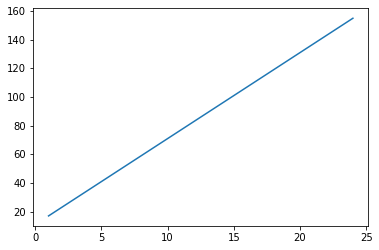

In [132]:
x = np.arange(1,25)
y = 6*x + 11
plt.figure()
plt.plot(x,y)
plt.show()

`figure()`函数的作用主要是用来设置绘图的基本参数，可以形象的看作是在绘图之前准备画布，可以通过设置相关参数来改变图形的基本设置，如图形的大小，背景颜色，边框等。

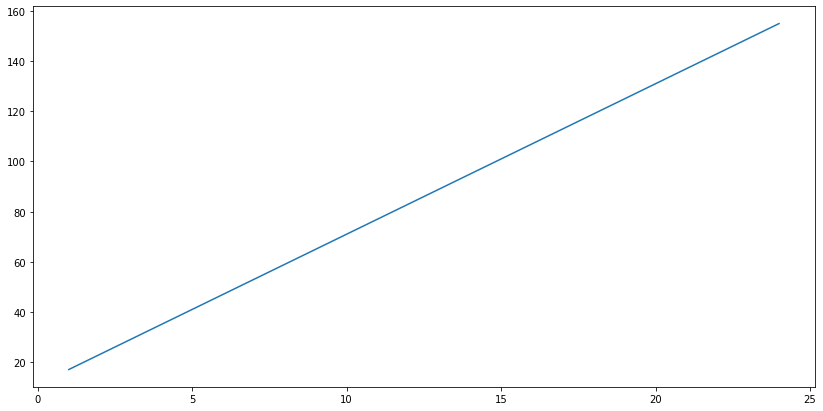

In [133]:
# 设置figure()的参数
#from matplotlib import pyplot as plt
x = np.arange(1,25)
y = 6*x + 11
plt.figure(figsize=(14,7))
plt.plot(x,y)
plt.show()

## `plot()`函数

`plot()`函数来自`matplotlib`库中的`pyplot`模块，可以通过改变其相关参数，改变图形的形状，颜色等：

- 线型， `-`:实线，`-`：虚线，`o`:圆标记
- 颜色， `b`:蓝色， `r`:红色，`k`:黑色 

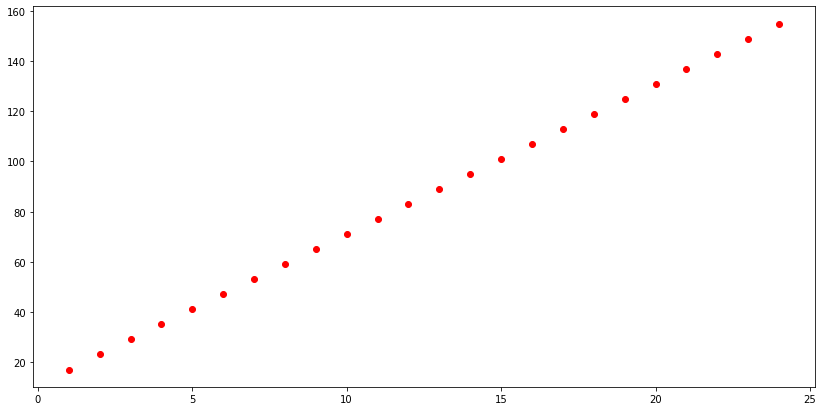

In [134]:
x = np.arange(1,25)
y = 6*x + 11
plt.figure(figsize=(14,7))
plt.plot(x,y,"or")
plt.show()

有时我们需要将多个曲线绘制在一起展示

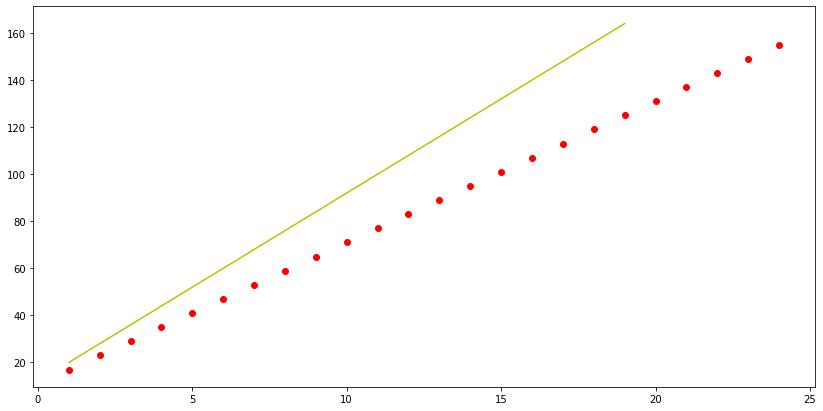

In [135]:
x = np.arange(1,25)
y = 6*x + 11
a = np.arange(1,20)
b = 8*a + 12
plt.figure(figsize=(14,7))
plt.plot(x,y,"or", a, b, "y")
plt.show()

为了能够区分不同的线，可以使用`legend()`函数加入图例

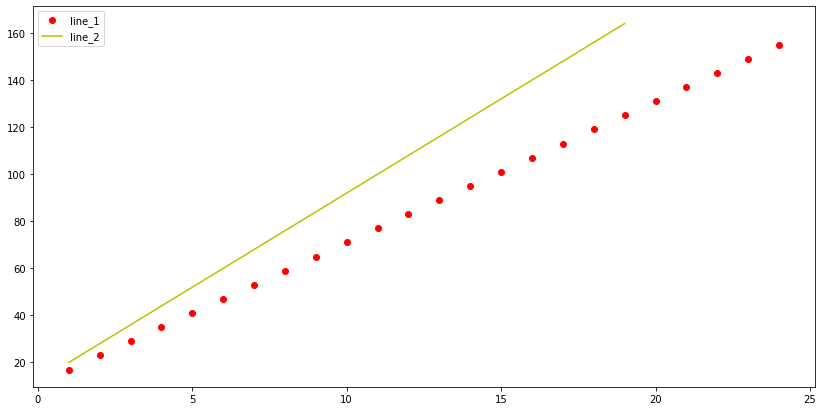

In [136]:
x = np.arange(1,25)
y = 6*x + 11
a = np.arange(1,20)
b = 8*a + 12
plt.figure(figsize=(14,7))
plt.plot(x,y,"or",label="line_1")
plt.plot(a,b,"y", label = "line_2")
plt.legend(loc=0)
plt.show()

## `subplot()`函数

`subplot()`用来绘制子图，以矩阵方式放置多张图

`subplot(nrows, ncols, plotNum)`

- `nrows`: 行数
- `ncols`: 列数
- `plotNum`: 指定的图形放置区域



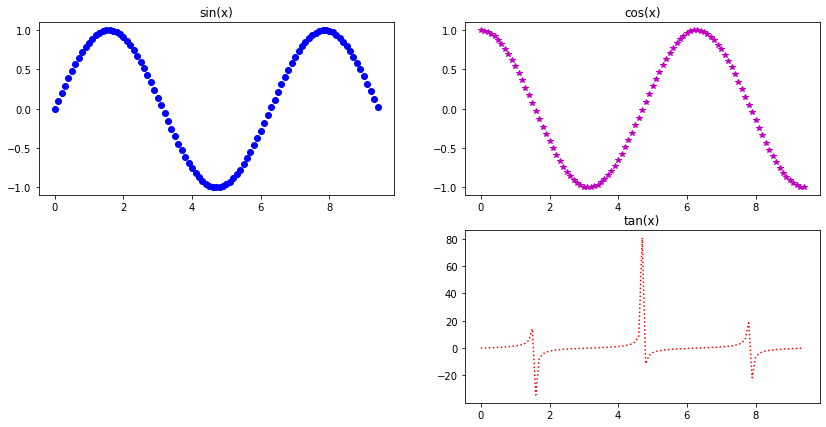

In [137]:
# 计算sin和cos曲线上的点x和y的坐标
x = np.arange(0, 3*np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)
y_tan = np.tan(x)

# 绘制画板
plt.figure(figsize=(14,7))

# 建立网格，2行2列
# 第一张图
plt.subplot(2,2,1)
plt.plot(x,y_sin,"ob")
plt.title("sin(x)")

# 第二张图
plt.subplot(2,2,2)
plt.plot(x,y_cos,"*m")
plt.title("cos(x)")

# 第三张图
plt.subplot(2,2,4)
plt.plot(x,y_tan,":r")
plt.title("tan(x)")

plt.show()


另外一种方法是使用`plt.subplots()`函数.

Text(0.5, 1.0, 'tan(x)')

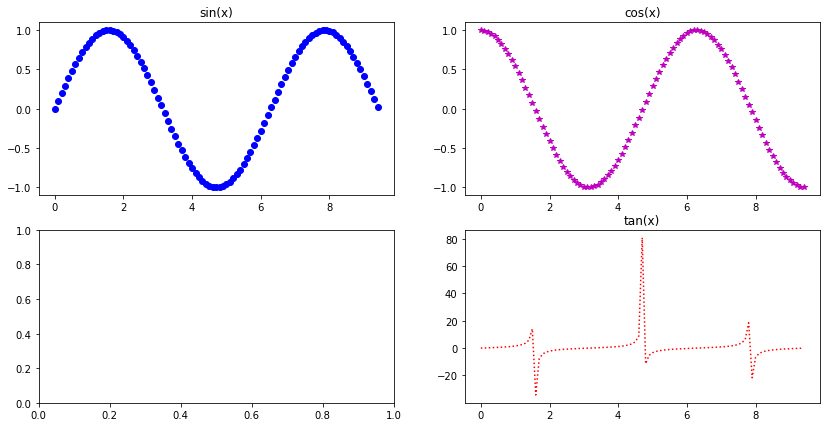

In [138]:
fig, ax = plt.subplots(2,2, figsize = (14,7))
#fig.set_facecolor('lightgrey')
ax[0,0].plot(x,y_sin,"ob")
ax[0,0].set_title("sin(x)")
ax[0,1].plot(x,y_cos,"*m")
ax[0,1].set_title("cos(x)")
#fig.delaxes(ax[1,0])
ax[1,1].plot(x,y_tan,":r")
ax[1,1].set_title("tan(x)")

Text(0.5, 1.0, 'tan(x)')

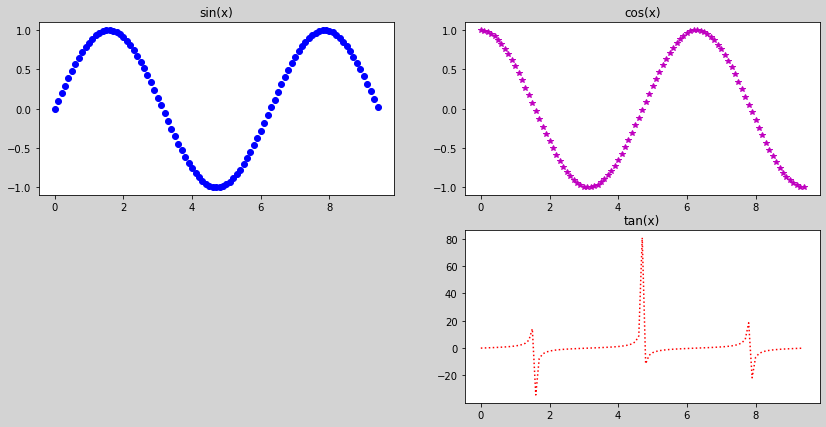

In [48]:
fig, ax = plt.subplots(2,2)
fig.set_figheight(7)
fig.set_figwidth(14)
fig.set_facecolor('lightgrey')
ax[0,0].plot(x,y_sin,"ob")
ax[0,0].set_title("sin(x)")
ax[0,1].plot(x,y_cos,"*m")
ax[0,1].set_title("cos(x)")
fig.delaxes(ax[1,0])
ax[1,1].plot(x,y_tan,":r")
ax[1,1].set_title("tan(x)")

# Linear Regresssion

In [139]:
# 从sklearn中引入linear_model
from sklearn import linear_model

In [140]:
# 构造数据，注意这里要求x一定是有两个维度
x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([5, 20, 14, 32, 22, 38])

In [141]:
x

array([[ 5],
       [15],
       [25],
       [35],
       [45],
       [55]])

In [92]:
x.shape

(6, 1)

In [91]:
y

array([ 5, 20, 14, 32, 22, 38])

In [93]:
y.shape

(6,)

In [143]:
# 将类实例化为对象
model = linear_model.LinearRegression()
# fit_intercept：bool量，选择是否需要计算截距，默认为True，如果中心化了的数据可以选择false
# model = linear_model.LinearRegression(fit_intercept = True)

In [144]:
dir(model)

['__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_check_n_features',
 '_decision_function',
 '_estimator_type',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_preprocess_data',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_intercept',
 '_validate_data',
 'copy_X',
 'fit',
 'fit_intercept',
 'get_params',
 'n_jobs',
 'normalize',
 'positive',
 'predict',
 'score',
 'set_params']

In [115]:
help(model)

Help on LinearRegression in module sklearn.linear_model._base object:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, normalize=False, copy_X=True, n_jobs=None, positive=False)
 |  
 |  Ordinary least squares Linear Regression.
 |  
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |  
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |  
 |  normalize : bool, default=False
 |      This parameter is ignored when ``fit_intercept`` is set to False.
 |      If True, the regressors X will be normalized before regression by
 |      subt

In [145]:
# 通过对象调用回归方法
model.fit(x,y)

LinearRegression()

In [146]:
# intercept is a scalar
print(f"intercept: {model.intercept_}")
# slope is an array
print(f"slope: {model.coef_}")

intercept: 5.633333333333329
slope: [0.54]


In [147]:
# 计算R square
r_sq = model.score(x, y)
print(f"coefficient of determination: {r_sq}")

coefficient of determination: 0.715875613747954


In [148]:
# 使用估计模型进行预测
y_pred = model.predict(x) # In-sample prediction
print(f"predicted response:\n{y_pred}")

predicted response:
[ 8.33333333 13.73333333 19.13333333 24.53333333 29.93333333 35.33333333]


In [149]:
y_pred = model.intercept_ + model.coef_ * x
print(f"predicted response:\n{y_pred}")

predicted response:
[[ 8.33333333]
 [13.73333333]
 [19.13333333]
 [24.53333333]
 [29.93333333]
 [35.33333333]]


In [150]:
# 样本外预测
x_new = np.arange(5).reshape((-1, 1))
y_new = model.predict(x_new)
y_new

array([5.63333333, 6.17333333, 6.71333333, 7.25333333, 7.79333333])

In [151]:
# 多元线性回归
x = [[0, 1], [5, 1], [15, 2], [25, 5], [35, 11], [45, 15], [55, 34], [60, 35]]
y = [4, 5, 20, 14, 32, 22, 38, 43]
x, y = np.array(x), np.array(y)

In [152]:
# 类实例化为对象，并调用方法
model = linear_model.LinearRegression().fit(x, y)

In [153]:
r_sq = model.score(x, y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {model.intercept_}")

print(f"coefficients: {model.coef_}")

coefficient of determination: 0.8615939258756775
intercept: 5.52257927519819
coefficients: [0.44706965 0.25502548]


In [154]:
# 样本内预测
y_pred = model.predict(x)
print(f"in-sample predicted response:\n{y_pred}")

# 样本外预测
x_new = np.arange(10).reshape((-1, 2))
y_new = model.predict(x_new)
print(f"out-of-sample predicted response:\n{y_new}")

in-sample predicted response:
[ 5.77760476  8.012953   12.73867497 17.9744479  23.97529728 29.4660957
 38.78227633 41.27265006]
out-of-sample predicted response:
[ 5.77760476  7.18179502  8.58598528  9.99017554 11.3943658 ]
